In [95]:
import random

import torch

from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from torchvision.models import resnet18

import matplotlib.pyplot as plt

from utils.dataset import BaseImageFolderDataset, DomainDataset
from utils.sampler import DomainBatchSampler
from utils.criterion import MMD, Coral
from utils.transforms import base_transforms, train_transforms
from utils.metrics import bundle, metrics_with_mask, accuracy, mmd
from utils.trainer import train

In [96]:
GPU = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
SEED = 42

TRAIN_FRACTION = 0.001
LEARNING_RATE = 1e-4
BATCH_SIZE = 32

In [97]:
random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch CUDA
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# PyTorch backend determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [98]:
def plot_training_metrics(metrics_dict):
    """
    Plot training and validation metrics from a dictionary.

    Args:
        metrics_dict: Dictionary containing lists of metrics for each epoch
                      Expected keys: 'train_loss', 'train_acc1', 'train_acc5',
                                   'val_loss', 'val_acc1', 'val_acc5'
    """
    epochs = range(1, len(metrics_dict['train_loss']) + 1)

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Loss curves
    ax1.plot(epochs, metrics_dict['train_loss'],
             'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, metrics_dict['val_loss'],
             'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Accuracy curves (Top-1 and Top-5)
    ax2.plot(epochs, metrics_dict['train_acc1'],
             'b-', label='Train Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['val_acc1'],
             'r-', label='Val Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['train_acc5'], 'b--',
             label='Train Top-5', linewidth=2, alpha=0.7)
    ax2.plot(epochs, metrics_dict['val_acc5'], 'r--',
             label='Val Top-5', linewidth=2, alpha=0.7)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [99]:
class VisDA2017Source(BaseImageFolderDataset):
    URL = 'http://csr.bu.edu/ftp/visda17/clf/train.tar'
    ARCHIVE_NAME = 'train.tar'
    EXTRACTED_FOLDER = 'train'


class VisDA2017Target(BaseImageFolderDataset):
    URL = 'http://csr.bu.edu/ftp/visda17/clf/test.tar'
    ARCHIVE_NAME = 'test.tar'
    EXTRACTED_FOLDER = 'test'


class VisDA2017Validation(BaseImageFolderDataset):
    URL = ' http://csr.bu.edu/ftp/visda17/clf/validation.tar'
    ARCHIVE_NAME = 'validation.tar'
    EXTRACTED_FOLDER = 'validation'

In [100]:
source_dataset = VisDA2017Source(
    './data', transform=train_transforms, download=True
)

target_dataset = VisDA2017Target(
    './data', transform=base_transforms, download=True
)

val_dataset = VisDA2017Validation(
    './data', transform=base_transforms, download=True
)

In [101]:
len(source_dataset), len(target_dataset), len(val_dataset)

(152397, 72372, 55388)

In [102]:
# TODO: Delete after tesing utils

import numpy as np
from torch.utils.data import Subset

np.random.seed(42)

# Generate random indices for split
source_indices = np.arange(len(source_dataset))
target_indices = np.arange(len(target_dataset))
val_indices = np.arange(len(val_dataset))

np.random.shuffle(source_indices)
np.random.shuffle(target_indices)
np.random.shuffle(val_indices)

source_size = int(len(source_dataset) * TRAIN_FRACTION)
target_size = int(len(target_dataset) * TRAIN_FRACTION)
val_size = int(len(val_dataset) * TRAIN_FRACTION)

source_indices = list(source_indices[:source_size])
target_indices = list(target_indices[:target_size])
val_indices = list(val_indices[:val_size])

source_dataset = Subset(source_dataset, source_indices)
target_dataset = Subset(target_dataset, target_indices)
val_dataset = Subset(val_dataset, val_indices)

In [103]:
train_dataset = DomainDataset(source_dataset, target_dataset)

train_sampler = DomainBatchSampler(
    source_size=len(source_dataset),
    target_size=len(target_dataset),
    batch_size=BATCH_SIZE,
)

In [104]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_sampler=train_sampler,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=4
)

In [105]:
import torch.nn.functional as F


class Criterion(nn.Module):
    def __init__(self, model, lambda_mmd: float = 0.5):
        super().__init__()
        self.model = model
        self.lambda_mmd = lambda_mmd

        self.ce = torch.nn.CrossEntropyLoss()
        self.mmd = MMD()
        self.coral = Coral()

    def forward(self, pred: torch.Tensor, y: torch.Tensor):
        mask = y != -1

        cls_loss = self.ce(pred[mask], y[mask])

        mmd = torch.tensor(0, device=y.device)

        if (~mask).sum() > 0:
            feat_l1 = self.model._feat_l1
            feat_l3 = self.model._feat_l3
            feat_fl = self.model._features

            mmd_1 = self.mmd(feat_l1[mask], feat_l1[~mask])
            mmd_2 = self.mmd(feat_l3[mask], feat_l3[~mask])
            mmd_3 = self.mmd(feat_fl[mask], feat_fl[~mask])

            eps = 1e-6

            w1 = 1.0 / (mmd_1.detach() + eps)
            w2 = 1.0 / (mmd_2.detach() + eps)
            w3 = 1.0 / (mmd_3.detach() + eps)
            w_sum = w1 + w2 + w3
            w1, w2, w3 = w1 / w_sum, w2 / w_sum, w3 / w_sum

            mmd = w1 * mmd_1 + w2 * mmd_2 + w3 * mmd_3
            # mmd = 0.3 * mmd_1 + 0.5 * mmd_2 + 1.0 * mmd_3
            # mmd = 0.2 * mmd_1 + 0.4 * mmd_2 + 0.4 * mmd_3

        return cls_loss + self.lambda_mmd * mmd

In [106]:
model = resnet18(num_classes=12)

model.layer1.register_forward_hook(
    lambda m, i, o: setattr(model, '_feat_l1', o.mean([2, 3]))
)
model.layer3.register_forward_hook(
    lambda m, i, o: setattr(model, '_feat_l3', o.mean([2, 3]))
)
model.avgpool.register_forward_hook(
    lambda m, i, o: setattr(model, '_features', torch.flatten(o, 1))
)

In [107]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [108]:
loss = Criterion(model, lambda_mmd=0.7)

In [109]:
metric_funcs = [metrics_with_mask(accuracy), mmd]

In [110]:
metrics_3 = train(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    loss,
    bundle(metric_funcs),
    epochs=200,
    # start_epoch=0,
    checkpoint_interval=200,
    checkpoint_path='.',
    device=GPU,
    # summary_writer=SummaryWriter(log_dir='./logs/resnet_mmd')
)

Epoch   1 | Train acc1: 9.0278 | Train acc5: 49.3056 | Train mmd: 1.0038 | Train loss: 3.2629 | Val acc1: 6.8614 | Val acc5: 47.6223 | Val loss: 2.4913


Epoch   2 | Train acc1: 14.5833 | Train acc5: 56.2500 | Train mmd: 0.6891 | Train loss: 3.0190 | Val acc1: 5.2989 | Val acc5: 31.4538 | Val loss: 2.7066


Epoch   3 | Train acc1: 16.6667 | Train acc5: 70.1389 | Train mmd: 0.6665 | Train loss: 2.7571 | Val acc1: 6.8614 | Val acc5: 32.0652 | Val loss: 2.8144


Epoch   4 | Train acc1: 18.7500 | Train acc5: 70.8333 | Train mmd: 0.6660 | Train loss: 2.7550 | Val acc1: 9.0353 | Val acc5: 33.6277 | Val loss: 2.7568


Epoch   5 | Train acc1: 17.3611 | Train acc5: 70.8333 | Train mmd: 0.5635 | Train loss: 2.6579 | Val acc1: 7.4728 | Val acc5: 40.4891 | Val loss: 2.6338


...

Epoch 196 | Train acc1: 80.5556 | Train acc5: 97.9167 | Train mmd: 0.3817 | Train loss: 0.8867 | Val acc1: 22.7582 | Val acc5: 61.0734 | Val loss: 4.3184


Epoch 197 | Train acc1: 81.9444 | Train acc5: 97.9167 | Train mmd: 0.3822 | Train loss: 0.8528 | Val acc1: 20.5842 | Val acc5: 57.3370 | Val loss: 3.8112


Epoch 198 | Train acc1: 78.4722 | Train acc5: 98.6111 | Train mmd: 0.3731 | Train loss: 0.9888 | Val acc1: 25.8832 | Val acc5: 57.9484 | Val loss: 2.9744


Epoch 199 | Train acc1: 77.7778 | Train acc5: 94.4444 | Train mmd: 0.3590 | Train loss: 1.0512 | Val acc1: 14.6739 | Val acc5: 59.5109 | Val loss: 3.1606


Epoch 200 | Train acc1: 81.9444 | Train acc5: 98.6111 | Train mmd: 0.3730 | Train loss: 0.8127 | Val acc1: 19.0217 | Val acc5: 60.1223 | Val loss: 3.3575
Saving checkpoint...OK


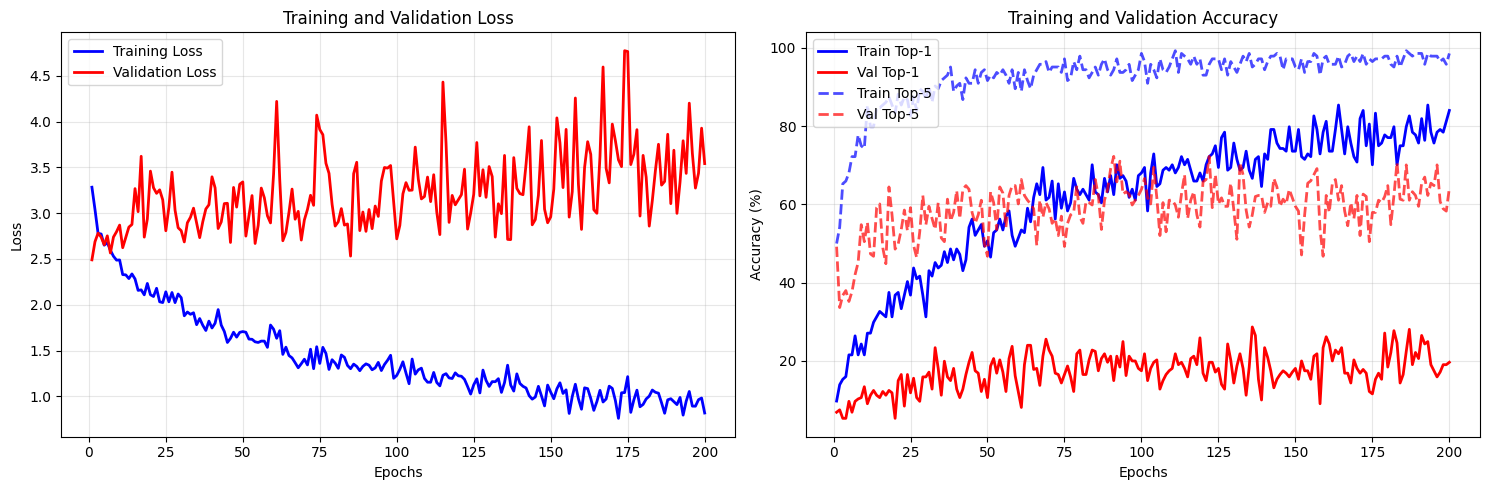

In [111]:
plot_training_metrics(metrics)  # type: ignore

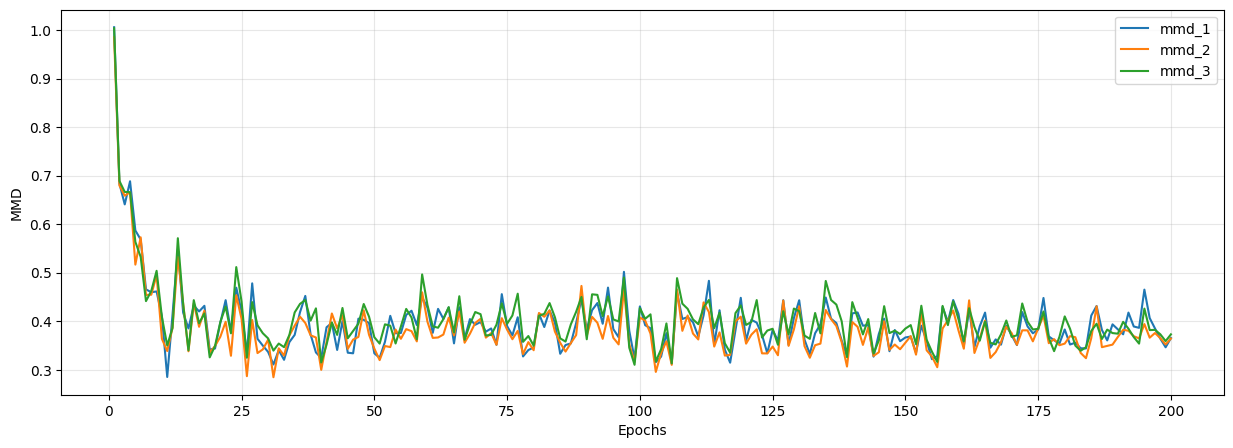

In [112]:
epochs = range(1, 201)
fig, ax1 = plt.subplots(1, figsize=(15, 5))
ax1.plot(epochs, metrics['train_mmd'], label='mmd_1')  # type: ignore
ax1.plot(epochs, metrics_2['train_mmd'], label='mmd_2')  # type: ignore
ax1.plot(epochs, metrics_3['train_mmd'], label='mmd_3')  # type: ignore
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MMD')
ax1.legend()
ax1.grid(True, alpha=0.3)